# Error models for $\alpha + {}^{44}$Ca elastic scattering: a comparison by evidence

This notebook is more of a small study than a demonstration. We have one real measurement and one optical potential, and the only thing we'll change is the **error model**: five different statements about what the disagreement between our model and the data means. Then we'll ask the data which statement they prefer, in two separate ways. The first is the [Bayesian evidence](https://en.wikipedia.org/wiki/Marginal_likelihood), and the second is how well each error model predicts angles it was never shown.

The data are differential elastic cross sections, as a ratio to the [Rutherford](https://en.wikipedia.org/wiki/Rutherford_scattering) cross section, for $^{44}$Ca($\alpha,\alpha$) at 29 MeV. They come from [EXFOR F0567](https://www-nds.iaea.org/exfor/servlet/X4sSearch5?EntryID=150567), measured by [Oeschler *et al.*, Phys. Rev. Lett. **28**, 694 (1972)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694). Oeschler *et al.* report no uncertainties at all, so every error model below has to infer its own, and that's exactly what makes the comparison interesting.

It's worth looking at the [`jitr` quickstart tutorials](https://beykyle.github.io/jitr/getting-started.html) alongside this one. In a sense this notebook is their successor: with `rxmc` we can build more careful statistical models on top of the same physics, including a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) for model discrepancy in the style of [Kennedy & O'Hagan (2001)](https://doi.org/10.1111/1467-9868.00294), which the `gp_discrepancy` notebook introduces.

Recipes: 7, 10, 11, 13, 17, 18

In [1]:
import corner
import dynesty
import jitr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotstyle
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    woods_saxon_safe,
)
from scipy import stats
from sklearn.gaussian_process.kernels import Matern

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

## The data

We'll take every fourth angle of the $^{44}$Ca set. That leaves 73 points between 15 and 174 degrees, which is plenty to pin down the diffraction pattern without making every fit four times slower. A ratio to Rutherford is dimensionless, so there are no units to convert. The kinematics the model needs go in `meta`, and since nothing was reported, the error column is just zeros.

In [2]:
df = pd.read_csv("data/alpha_ca_ratio_ruth.csv")
df = df[df["target"] == "Ca44"].iloc[::4]
reaction = jitr.reactions.ElasticReaction(target=(44, 20), projectile=(4, 2))
E_lab = 29.0
meta = {"reaction": reaction, "Elab": E_lab, "quantity": "dXS/dRuth"}
angles = np.deg2rad(df["angle_cm_deg"].to_numpy())
ratio = df["ratio_to_rutherford"].to_numpy()
data = rx.Dataset(
    angles, ratio, np.zeros(ratio.size), label="44Ca(a,a) 29 MeV", meta=meta
)
x_fine = np.deg2rad(np.linspace(10.0, 178.0, 220))

In [3]:
print(
    f"{data.n} points between {np.rad2deg(angles.min()):.0f} and "
    f"{np.rad2deg(angles.max()):.0f} degrees"
)

73 points between 15 and 174 degrees


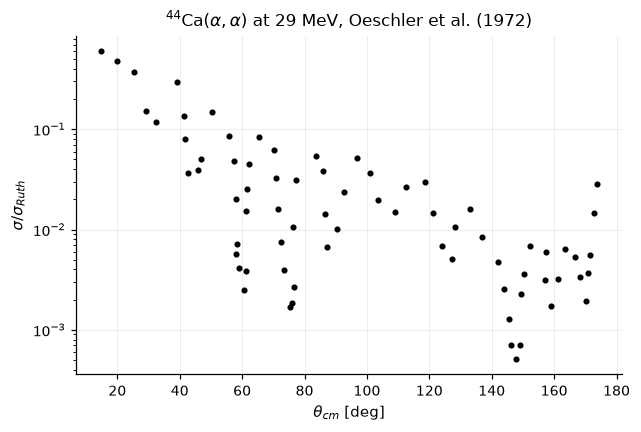

In [4]:
fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title=r"$^{44}$Ca($\alpha,\alpha$) at 29 MeV, Oeschler et al. (1972)",
)
plt.show()

## The optical model

We use the same model as the `jitr` quickstart: a [Woods–Saxon](https://en.wikipedia.org/wiki/Woods%E2%80%93Saxon_potential) potential, plus the Coulomb potential of a uniformly charged sphere of radius $1.3\,A^{1/3}$ fm, with radii measured in units of $A^{1/3}$ fm. The real and imaginary volume terms share one geometry, which leaves four free parameters: $V$, $W$, $r$ and $a$. For priors we take the quickstart's typical $\alpha$-nucleus values, truncated at zero so the depths stay physical (recipe 13).

Thirty partial waves are enough to converge at this energy. The solver's default basis size agrees with the fully converged solution to within a few per cent, even at the deepest diffraction minima. That's far smaller than any of the errors we're about to infer, and it runs about two hundred times faster.

In [5]:
A13 = 44 ** (1 / 3)


def central(r, V, W, R, a):
    return -(V + 1j * W) * woods_saxon_safe(r, R * A13, a)


def coulomb(r):
    return coulomb_charged_sphere(
        r, reaction.target.Z * reaction.projectile.Z, 1.3 * A13
    )


params = [
    rx.Parameter("V", prior=stats.norm(150.0, 20.0), bounds=(0.0, np.inf), latex="V"),
    rx.Parameter("W", prior=stats.norm(20.0, 10.0), bounds=(0.0, np.inf), latex="W"),
    rx.Parameter("r", prior=stats.norm(1.4, 0.3), bounds=(0.8, 2.0), latex="r"),
    rx.Parameter("a", prior=stats.norm(0.5, 0.2), bounds=(0.2, 1.0), latex="a"),
]
omp = rx.reactions.ElasticXS(
    "dXS/dRuth",
    central,
    lambda r: 0.0 * r,
    lambda ws, *x: (tuple(x), (), ()),
    params,
    coulomb=coulomb,
    lmax=30,
)
theta_0 = np.array([150.0, 20.0, 1.4, 0.5])

In [6]:
# we always draw the model on a fine grid: evaluated only at the (downsampled)
# data angles, the diffraction pattern aliases and the curve looks ragged
on_fine = omp.bind(x_fine, meta)

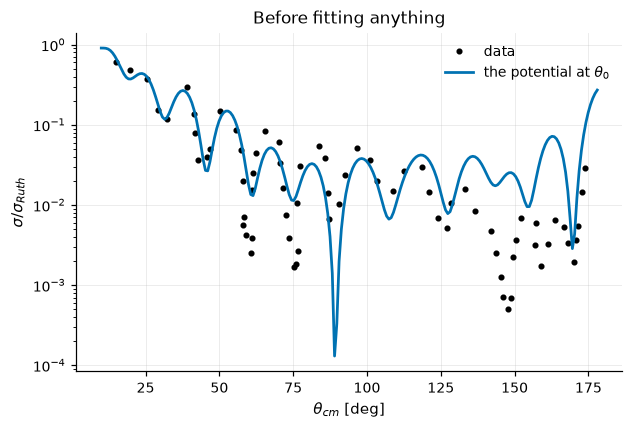

In [7]:
fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.plot(
    np.rad2deg(x_fine),
    on_fine(*theta_0),
    color=plotstyle.COLOURS[0],
    label=r"the potential at $\theta_0$",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Before fitting anything",
)
ax.legend()
plt.show()

## The error-model ladder

The data span three decades, and although their errors were never reported, they're presumably multiplicative: a few per cent of the cross section, whatever its size. Multiplicative errors become additive in log space, so that's where we'll compare (recipe 10). Passing `space=tf.log` to a `Comparison` transforms the data once and every prediction along with it. Later on, `problem.log_jacobian()` will be what lets us compare a log-space evidence with a linear-space one.

Since nothing was reported, every rung sets `statistical=False`, and the inferred terms *are* the whole covariance. These are the five rungs we'll climb:

| label | error model |
|---|---|
| `L0` | constant noise in log space, $\sigma = \epsilon$ on every point |
| `E0` | fractional noise in linear space, $\sigma_i = \epsilon\, y_{m,i}$ |
| `L2y` | `L0` plus a free normalisation mode, $\eta\, y_m$ (the `jitr` notebook's model) |
| `Lgp` | `L0` plus a [Matérn](https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function)(5/2) Gaussian process in $u = \theta/\pi$ with a free amplitude |
| `Lgpn` | the same, but with an amplitude that **grows with angle** |

`Lgpn` is the only rung that can say *where* the potential fails, rather than just how badly. A stationary kernel with a constant amplitude declares the same uncertainty at every angle, and nobody really believes that about an optical model: forward angles, dominated by Coulomb scattering, are much easier to get right than the backward ones.

A couple of bookkeeping notes. We reuse the same `log_eps` parameter object across rungs, and each `Problem` compiles independently of the others (recipe 18). The priors on the error scales are log-uniform between 5 % and 200 %, as in the `jitr` notebook (recipe 13).

In [8]:
comp_log = rx.Comparison(data, omp, space=tf.log)
comp_lin = rx.Comparison(data, omp)
log_eps = rx.Parameter(
    "log_eps",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log\epsilon",
)
log_eta = rx.Parameter(
    "log_eta",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log\eta",
)
log_amp = rx.Parameter(
    "log_A",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log A",
)
log_ell = rx.Parameter(
    "log_ell",
    prior=stats.uniform(np.log(0.02), np.log(1.0) - np.log(0.02)),
    latex=r"\log\ell",
)
log_amp_n = rx.Parameter(
    "log_A_n",
    prior=stats.uniform(np.log(0.05), np.log(2.0) - np.log(0.05)),
    latex=r"\log A_n",
)
amp_slope = rx.Parameter("amp_slope", prior=stats.norm(1.0, 1.0), latex="s_A")
gp = T.kernel(
    Matern(0.1, nu=2.5),
    on=comp_log,
    coords=lambda x: x / np.pi,
    amplitude=T.constant_amplitude,
    amplitude_params=(log_amp,),
    params=[log_ell],
)

gp_n = T.kernel(
    Matern(0.1, nu=2.5),
    on=comp_log,
    coords=lambda x: x / np.pi,
    amplitude=T.exp_growth_amplitude(1.0),
    amplitude_params=(log_amp_n, amp_slope),
    params=[log_ell],
)

In [9]:
ladder = {
    "L0": rx.Constraint([comp_log], terms=[T.noise(log_eps)], statistical=False),
    "E0": rx.Constraint(
        [comp_lin], terms=[T.noise_fraction(log_eps)], statistical=False
    ),
    "L2y": rx.Constraint(
        [comp_log],
        terms=[T.noise(log_eps), T.normalization(log_eta)],
        statistical=False,
    ),
    "Lgp": rx.Constraint([comp_log], terms=[T.noise(log_eps), gp], statistical=False),
    "Lgpn": rx.Constraint(
        [comp_log], terms=[T.noise(log_eps), gp_n], statistical=False
    ),
}
problems = {name: rx.Problem([c]) for name, c in ladder.items()}

In [10]:
for name, p in problems.items():
    print(f"{name:4s} columns: {p.names}")

L0   columns: ['V', 'W', 'r', 'a', 'log_eps']
E0   columns: ['V', 'W', 'r', 'a', 'log_eps']
L2y  columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_eta']
Lgp  columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_ell', 'log_A']
Lgpn columns: ['V', 'W', 'r', 'a', 'log_eps', 'log_ell', 'log_A_n', 'amp_slope']


## Running the ladder

Optical-model posteriors are strongly correlated and often multimodal, so we'll use [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) ([Skilling 2006](https://doi.org/10.1214/06-BA127)) through [dynesty](https://dynesty.readthedocs.io/) ([Speagle 2020](https://doi.org/10.1093/mnras/staa278)). It copes well with that kind of posterior, and it computes the evidence we're about to compare as a by-product.

In [11]:
def fit_nested(problem, seed, nlive=80, dlogz=1.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    return sampler.results

In [12]:
results, samples = {}, {}
for i, (name, p) in enumerate(problems.items()):
    results[name] = fit_nested(p, seed=i)
    samples[name] = results[name].samples_equal(rstate=np.random.default_rng(i))

In [13]:
for name, res in results.items():
    print(
        f"{name:4s} log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}   "
        f"{int(np.sum(res.ncall)):6d} calls"
    )

L0   log Z =  -101.42 +/- 0.95    26153 calls
E0   log Z =   211.36 +/- 1.03    34980 calls
L2y  log Z =   -98.22 +/- 0.85    22672 calls
Lgp  log Z =   -92.18 +/- 0.95    30383 calls
Lgpn log Z =   -88.70 +/- 0.88    35387 calls


## Evidence, and what a Bayes factor is

The [marginal likelihood](https://en.wikipedia.org/wiki/Marginal_likelihood), or evidence, is the probability a model assigned to the data before we asked which parameters fit best. We get it by averaging the likelihood over the prior:

$$Z = \int p(\mathbf{y} \mid \theta)\, p(\theta)\, \mathrm{d}\theta .$$

Because it's an average, it rewards models that put their probability where the data actually landed, and it penalises models that spread probability thinly over parameter space they turned out not to need. It's an automatic [Occam's razor](https://en.wikipedia.org/wiki/Occam%27s_razor). The ratio of two evidences is the [Bayes factor](https://en.wikipedia.org/wiki/Bayes_factor), and it tells us how much the data should shift our relative belief in one error model over another. Nested sampling computes $\log Z$ directly, which is the main reason we're using it here.

There are two practical things to keep in mind. First, a Bayes factor depends on the priors, not just on how good the best fit is, so the prior widths are part of the claim we're making. That's why we stated them explicitly above. Second, evidences computed in different comparison spaces aren't comparable as they stand. The log transform stretches and squeezes the data axis, so the densities pick up a factor from the [change of variables](https://en.wikipedia.org/wiki/Probability_density_function#Function_of_random_variables_and_change_of_variables_in_the_probability_density_function). Adding `problem.log_jacobian()` accounts for it and puts the log-space rungs in the same units as the linear-space `E0`.

To compare two rungs we'll use `compare_logz`. It calls the result a tie unless the difference is more than twice the combined sampler error, because differences smaller than that are bookkeeping noise, not evidence.

In [14]:
logz = {
    name: rx.diagnostics.logz_summary(
        results[name].logz[-1] + problems[name].log_jacobian(),
        results[name].logzerr[-1],
    )
    for name in problems
}
best = max(logz, key=lambda n: logz[n][0])
comparisons = {
    name: rx.diagnostics.compare_logz(logz[best], logz[name])
    for name in problems
    if name != best
}

In [15]:
print(f"{'rung':5s} {'log Z (linear-space units)':>28s}")
for name, (mean, err, _) in logz.items():
    print(f"{name:5s} {mean:20.2f} +/- {err:.2f}")
print(f"\nbest rung: {best}")
for name, v in comparisons.items():
    verdict = {"a": f"{best} favoured", "b": f"{name} favoured", "tie": "tie"}
    print(
        f"{best} vs {name}: dlogZ = {v['dlogZ']:6.2f} +/- {v['err']:.2f}"
        f"  ->  {verdict[v['verdict']]}"
    )

rung    log Z (linear-space units)
L0                  213.05 +/- 0.95
E0                  211.36 +/- 1.03
L2y                 216.26 +/- 0.85
Lgp                 222.30 +/- 0.95
Lgpn                225.78 +/- 0.88

best rung: Lgpn
Lgpn vs L0: dlogZ =  12.72 +/- 1.29  ->  Lgpn favoured
Lgpn vs E0: dlogZ =  14.41 +/- 1.36  ->  Lgpn favoured
Lgpn vs L2y: dlogZ =   9.52 +/- 1.23  ->  Lgpn favoured
Lgpn vs Lgp: dlogZ =   3.48 +/- 1.30  ->  Lgpn favoured


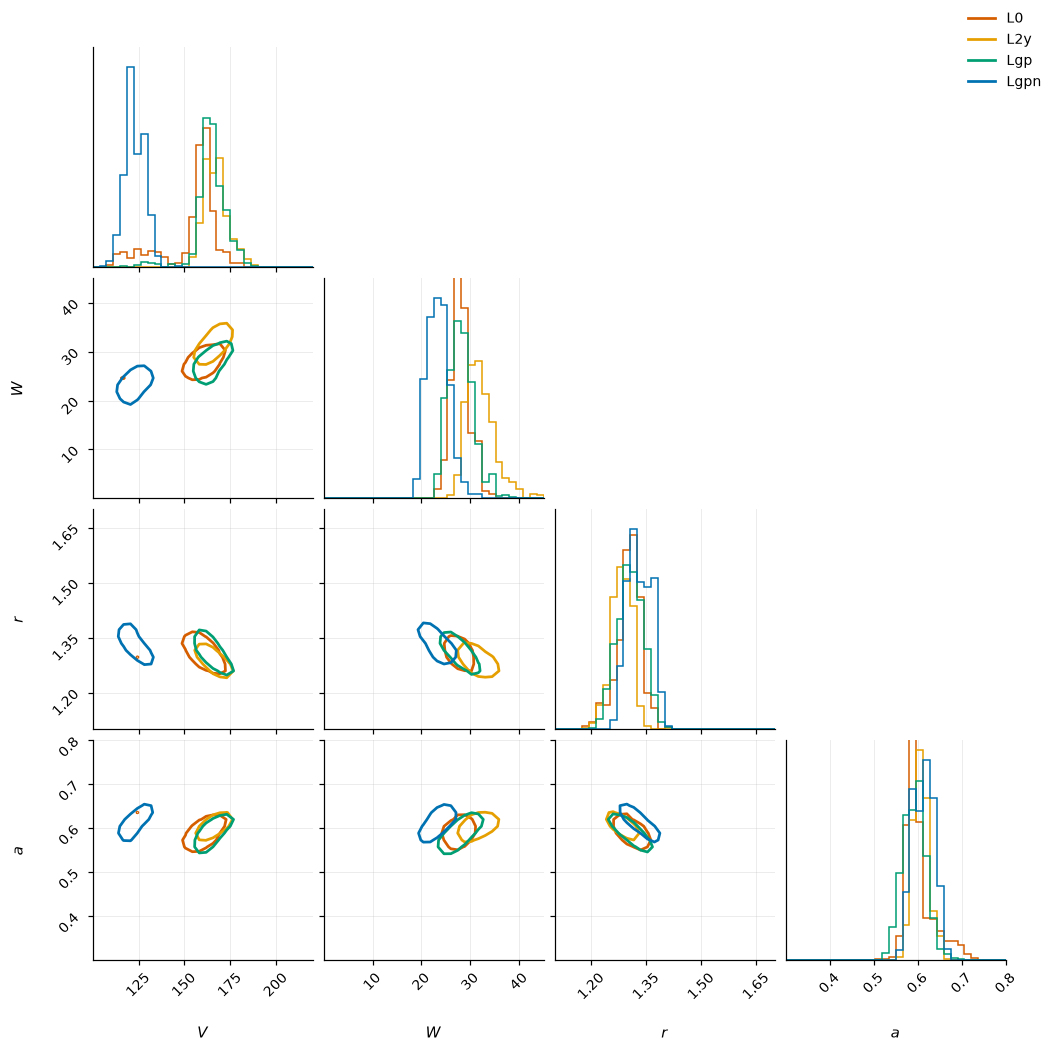

In [16]:
labels = [f"${q.latex}$" for q in params]
fig = None
rungs = [
    ("L0", plotstyle.COLOURS[1]),
    ("L2y", plotstyle.COLOURS[4]),
    ("Lgp", plotstyle.COLOURS[2]),
    ("Lgpn", plotstyle.COLOURS[0]),
]
for name, colour in rungs:
    fig = corner.corner(
        samples[name][:, problems[name].columns(params)],
        fig=fig,
        labels=labels,
        range=[(100, 220), (0, 45), (1.1, 1.7), (0.3, 0.8)],
        **plotstyle.corner_kwargs(
            color=colour,
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68,),
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in rungs],
    loc="upper right",
    fontsize=9,
)
plt.show()

## What each rung predicts (recipe 17)

Evidence tells us which error model the data prefer. It doesn't tell us whether *any* of them describes the data well, and for that we want the [posterior predictive](https://en.wikipedia.org/wiki/Posterior_predictive_distribution). By that we mean draws of $y_m(\theta)$ plus noise with the covariance each rung declared, not just the spread of the model curve.

`predictive_draws` gives exactly that. Its draws include $\Sigma$, so a rung with a large inferred noise produces wide draws even where its model curve is sharp. We'll compare the log-space rungs at the measured angles, and then check how well calibrated they are.

It's worth being clear about which terms these draws carry: *all* of them. A draw of the model plus its discrepancy alone is a statement about the model, not a prediction of a measurement, and comparing it with data would be comparing two different kinds of thing. The `gp_discrepancy` notebook writes out the equations for each. A coverage check only means something against the full predictive, which is what `predictive_draws` gives by default.

In [17]:
levels = np.linspace(0.1, 0.9, 9)
draws, coverage, cov68, width68 = {}, {}, {}, {}
for i, (name, _) in enumerate(rungs):
    p = problems[name]
    c = p.constraints[0]
    draws[name] = rx.diagnostics.predictive_draws(
        p, samples[name][::20], n_rep=2, rng=i, return_draws=True
    )
    coverage[name] = rx.diagnostics.coverage_curve(draws[name], c.y[c.active], levels)
    cov68[name] = rx.diagnostics.coverage_curve(draws[name], c.y[c.active], [0.68])[0]
    width68[name] = rx.diagnostics.sharpness(draws[name], transform=np.exp).mean()

In [18]:
for name, _ in rungs:
    print(
        f"{name:4s} 68 % predictive width = {width68[name]:6.3f} (ratio units)   "
        f"coverage at 0.68 = {cov68[name]:.2f}"
    )

L0   68 % predictive width =  0.076 (ratio units)   coverage at 0.68 = 0.79
L2y  68 % predictive width =  0.068 (ratio units)   coverage at 0.68 = 0.81
Lgp  68 % predictive width =  0.072 (ratio units)   coverage at 0.68 = 0.78
Lgpn 68 % predictive width =  0.068 (ratio units)   coverage at 0.68 = 0.77


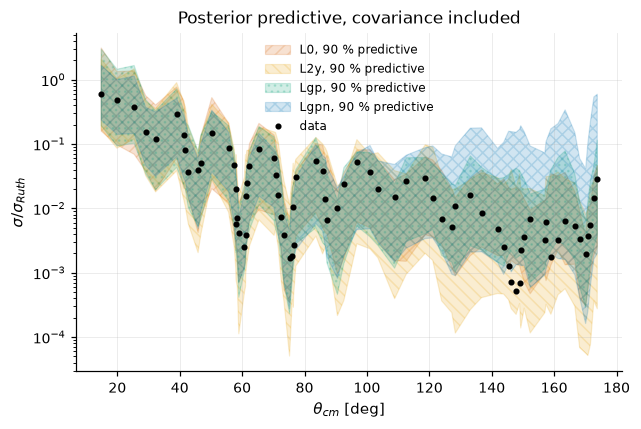

In [19]:
fig, ax = plt.subplots()
for (name, colour), hatch in zip(rungs, plotstyle.HATCHES):
    lo, hi = np.percentile(np.exp(draws[name]), [5, 95], axis=0)
    plotstyle.band(
        ax,
        np.rad2deg(angles),
        lo,
        hi,
        color=colour,
        hatch=hatch,
        label=f"{name}, 90 % predictive",
    )
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Posterior predictive, covariance included",
)
ax.legend(fontsize=8)
plt.show()

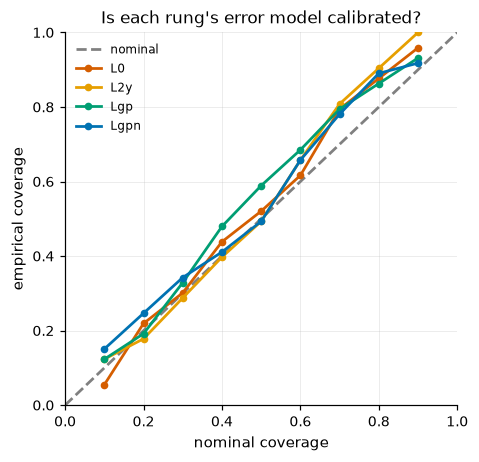

In [20]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
for name, colour in rungs:
    ax.plot(levels, coverage[name], "o-", color=colour, label=name)
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    xlim=(0, 1),
    ylim=(0, 1),
    title="Is each rung's error model calibrated?",
)
ax.legend(fontsize=8)
plt.show()

### Where the potential fails, not just how badly

The two GP rungs differ in only one respect: `Lgp` has a constant amplitude, while `Lgpn` has an amplitude that grows with angle. To see what that difference buys us, we can ask each of them for the mean-zero predictive about its own model on a fine angular grid. That's `grid_draws` with `terms=[gp]`: the kernel, and nothing else.

Let's be careful about what goes into that envelope. It carries two things: the posterior spread of the potential itself, and the discrepancy the kernel declares. With a constant amplitude, the discrepancy part is the same at every angle, so whatever shape the envelope has comes almost entirely from the spread of the potential. Sure enough, the `Lgp` envelope is 1.24 wide at 20 degrees, 2.01 at 90 and 1.42 at 170, so it's only 1.1 times wider at the back than at the front. Its *error model* is as unsure about forward angles as about backward ones. The `Lgpn` envelope is 0.52, 1.77 and 2.92 wide at the same angles, a back-to-front ratio of 5.6. Only `Lgpn` is telling us **where** the potential fails.

Keep in mind that these envelopes are statements about the model, not predictions of a measurement. They carry no experimental term, so we shouldn't lay them over the data. That's exactly the distinction `terms=` encodes, and the `gp_discrepancy` notebook spells out the equations.

In [21]:
gp_terms = {"Lgp": gp, "Lgpn": gp_n}
envelopes = {}
for name, term in gp_terms.items():
    p = problems[name]
    band = rx.predictive.grid_draws(
        p, omp.bind(x_fine, meta), x_fine, samples[name], terms=[term],
        levels=(16, 84), rng=3,
    )  # fmt: skip
    theta_med = np.median(samples[name], axis=0)
    mu = np.log(on_fine(*theta_med[p.columns(params)]))
    envelopes[name] = (band[1] - band[0], band[0] - mu, band[1] - mu)

In [22]:
for name, (w, _, _) in envelopes.items():
    at = [np.interp(np.deg2rad(a), x_fine, w) for a in (20, 90, 170)]
    print(
        f"{name:5s} 68 % envelope about the model at 20, 90, 170 deg: "
        + " ".join(f"{v:.3f}" for v in at)
        + f"   back/front = {at[2] / at[0]:.1f}"
    )

Lgp   68 % envelope about the model at 20, 90, 170 deg: 1.235 2.012 1.416   back/front = 1.1
Lgpn  68 % envelope about the model at 20, 90, 170 deg: 0.522 1.769 2.923   back/front = 5.6


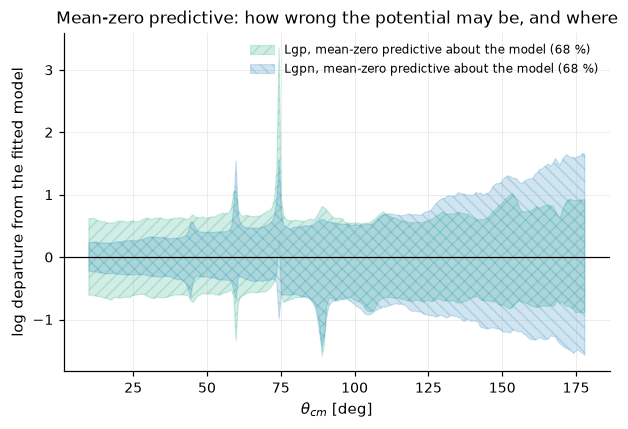

In [23]:
fig, ax = plt.subplots()
for (name, colour), hatch in zip(
    (("Lgp", plotstyle.COLOURS[2]), ("Lgpn", plotstyle.COLOURS[0])),
    plotstyle.HATCHES,
):
    _, lo, hi = envelopes[name]
    plotstyle.band(
        ax,
        np.rad2deg(x_fine),
        lo,
        hi,
        color=colour,
        hatch=hatch,
        label=f"{name}, mean-zero predictive about the model (68 %)",
    )
ax.axhline(0.0, color="k", lw=0.8)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel="log departure from the fitted model",
    title="Mean-zero predictive: how wrong the potential may be, and where",
)
ax.legend(fontsize=8)
plt.show()

### Are any of them calibrated?

On the data they were fitted to, all four rungs *over*-cover. 79 %, 81 %, 78 % and 77 % of the measured points fall inside their nominal 68 % intervals, with predictive widths of 0.076, 0.068, 0.072 and 0.068 in ratio units. So the inferred noise is a little more generous than the data need. We should expect that when one noise parameter has to cover a diffraction pattern whose model error is nowhere near uniform in angle. Notice also how little separates the rungs here.

That's the easy question, though, because these are the points each fit was shown. The held-out section below asks the hard one, and there the rungs separate sharply: 49 %, 60 %, 80 % and 63 % of the backward angles land inside the nominal 68 % band. Being well calibrated on the data we fitted is no evidence at all that we'll be calibrated on the data we didn't.

## Hold out the backward angles (recipe 11)

Now we'll fit each rung only to the angles below 90 degrees, and score how well it predicts the angles above. This is a form of [cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)), and the score we'll use, the log predictive density of the held-out points, is the one [Vehtari, Gelman & Gabry (2017)](https://doi.org/10.1007/s11222-016-9696-4) recommend. In `rxmc` this takes very little code: `masked_where` keeps every object and just masks the points, `complement()` flips the mask, and a chain from the fit can score the held-out problem directly.

The joint held-out log predictive answers a different question from the evidence. The evidence asks "which model best explains the data we fitted?", while the held-out score asks "which model best predicts what it hasn't seen?".

There's one subtlety. In `L2y` the normalisation, and in the GP rungs the kernel, *couple* the angles we fit to the ones we hold out: knowing the residuals on one side of the cut tells us something about the other. So the honest score isn't the marginal density of the held-out points, but the conditional $p(y_\mathrm{held} \mid y_\mathrm{fit}, \theta)$. Passing `given=p_fit` to both diagnostics computes exactly that (recipe 11). For `L0` nothing couples the two sides, and the conditional is the same as the marginal.

In [24]:
cut = np.deg2rad(90.0)
scores = {}
for i, (name, c) in enumerate(ladder.items()):
    if name == "E0":
        continue  # same space as L0 up to the noise model; the log rungs are the comparison
    fit = c.masked_where(lambda x: x < cut)
    p_fit, p_held = rx.Problem([fit]), rx.Problem([fit.complement()])
    res = fit_nested(p_fit, seed=10 + i)
    s = res.samples_equal(rstate=np.random.default_rng(10 + i))
    lp = rx.diagnostics.heldout_log_predictive(p_held, s[::5], given=p_fit)
    held_draws = rx.diagnostics.predictive_draws(
        p_held, s[::20], n_rep=2, rng=i, given=p_fit, return_draws=True
    )
    h = p_held.constraints[0]
    scores[name] = (
        rx.diagnostics.log_posterior_predictive(lp),
        rx.diagnostics.coverage_curve(held_draws, h.y[h.active], [0.68])[0],
        s,
        p_fit,
        p_held,
    )

In [25]:
for name, (score, cov, *_) in scores.items():
    print(
        f"{name:4s} held-out log predictive = {score:8.2f}   "
        f"68 % coverage of the held-out points = {cov:.2f}"
    )

L0   held-out log predictive =   -60.50   68 % coverage of the held-out points = 0.49
L2y  held-out log predictive =   -55.34   68 % coverage of the held-out points = 0.60
Lgp  held-out log predictive =   -50.45   68 % coverage of the held-out points = 0.80
Lgpn held-out log predictive =   -47.78   68 % coverage of the held-out points = 0.63


Finally, let's draw each rung's forecast past the cut, on the fine angular grid. Every term on this ladder is a function of angle and of the prediction: the noise, the normalisation mode, the kernel and its amplitude. That means `grid_draws` can carry the whole error model onto the grid, and the band it gives is a prediction of a *measurement*, which we can honestly lay over the held-out data.

One caveat: this is each rung's marginal predictive, not conditioned on the forward angles. For the rungs whose terms couple the two sides of the cut, it's therefore wider than the conditional predictive we used for the scores above.

In [26]:
forecast = {}
for i, (name, _) in enumerate(rungs):
    _, _, s, p_fit, _ = scores[name]
    forecast[name] = rx.predictive.grid_draws(
        p_fit, on_fine, x_fine, s[::25], n_rep=2, physical=True, levels=(5, 95), rng=i
    )

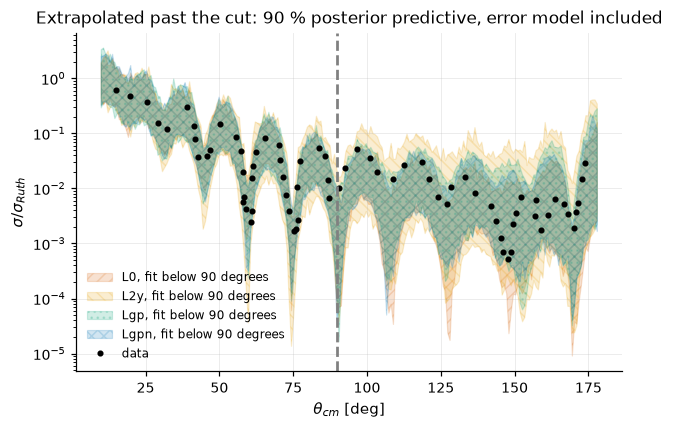

In [27]:
fig, ax = plt.subplots()
for (name, colour), hatch in zip(rungs, plotstyle.HATCHES):
    lo, hi = forecast[name]
    plotstyle.band(
        ax,
        np.rad2deg(x_fine),
        lo,
        hi,
        color=colour,
        hatch=hatch,
        label=f"{name}, fit below 90 degrees",
    )
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.axvline(90.0, color="0.5", ls="--")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Extrapolated past the cut: 90 % posterior predictive, error model included",
)
ax.legend(fontsize=8)
plt.show()

## Takeaways

- We used one comparison, one potential and five covariances. The whole ladder is just a dictionary of constraints, and every problem compiles on its own.
- Log space is where multiplicative errors become additive, and the Jacobian is what makes a log-space evidence comparable with a linear-space fit.
- Evidence and held-out prediction ask different questions, and here they agree: `Lgpn`, the GP whose amplitude grows with angle, wins both. Its evidence margin over the constant-amplitude `Lgp` is real but slim, $\Delta \log Z = 3.5 \pm 1.3$, only just past the two-sigma bar `compare_logz` insists on. Its held-out log predictive is the best on the ladder, $-47.8$ against $-50.5$.
- It's also the only rung that comes close to being calibrated where it counts. Past the cut, the four rungs cover 49 %, 60 %, 80 % and 63 % of the held-out points at a nominal 68 %: `L0` is far too narrow, `Lgp` too wide, and `Lgpn` nearly right. On the fitted data all four over-cover and look much alike, which is exactly why in-sample calibration isn't evidence of anything.
- *Where* a model fails is prior knowledge worth stating. A stationary kernel with a constant amplitude declares the same uncertainty at every angle. Letting the amplitude grow turns the discrepancy into a claim about which angles we can trust the potential at, and the data reward it.
- Light-ion potentials are famously ambiguous: several families of parameters give nearly the same cross section. The `L0` posterior above has a second family near $V \approx 125$ MeV alongside the main one at $V \approx 165$ MeV, and it's the prior, not the data, that decides how much weight each gets. The `jitr` calibration notebook discusses this discrete ambiguity in more detail.